In [312]:
import torch
import time
import imageio
import numpy as np
import pandas as pd 
import torch.nn as nn
import seaborn as sns
import torch.optim as optim
from torchdiffeq import odeint
import matplotlib.pyplot as plt
from IPython.display import clear_output

## ODE Solver

In [313]:
def euler_solver(func, y0, t):
    """
    func: ODE function f(t, y)
    y0: initial state (tensor: [batch, dim])
    t: time tensor, shape [T]
    """
    ys = [y0]
    y = y0
    
    for i in range(1, len(t)): 
        dt = t[i] - t[i - 1]
        y = y + func(t[i - 1], y) * dt
        ys.append(y)

    return torch.stack(ys, dim=0)  # shape: [T, batch, dim]

In [314]:
def improved_euler_solver(func, y0, t):
    """
    func: ODE function f(t, y)
    y0: initial state (tensor: [batch, dim]
    t: time tensor, shape [T]
    """
    ys = [y0]
    y = y0 
    for i in range(1, len(t)):
        dt = t[i] - t[i - 1]
        k1 = func(t[i-1], y)
        k2 = y + k1 * dt
        y = y + (k1 + func(t[i], k2)) * dt / 2
        ys.append(y)
    return torch.stack(ys, dim=0)


In [315]:
def rk2_solver(func, y0, t):
    """
    func: ODE function f(t, y)
    y0: initial state (tensor: [batch, dim]
    t: time tensor, shape [T]
    """
    ys = [y0]
    y = y0 
    for i in range(1, len(t)):
        dt = t[i] - t[i - 1]
        k1 = func(t[i-1], y)
        k2 = func(t[i-1] + dt/2, y + k1 * dt / 2)
        y = y + k2 * dt
        ys.append(y)
    return torch.stack(ys, dim=0)

In [316]:
def rk4_solver(func, y0, t):
    """
    func: ODE function f(t, y)
    y0: initial state (tensor: [batch, dim]
    t: time tensor, shape [T]
    """
    ys = [y0]
    y = y0 
    for i in range(1, len(t)):
        dt = t[i] - t[i - 1]
        k1 = func(t[i-1], y)
        k2 = func(t[i-1] + dt/2, y + k1 * dt / 2)
        k3 = func(t[i-1] + dt/2, y + k2 * dt / 2)
        k4 = func(t[i-1] + dt, y + k3 * dt)
        y = y + (k1 + 2*k2 + 2*k3 + k4) * dt / 6
        ys.append(y)
    return torch.stack(ys, dim=0)

## Neural ODE

In [317]:
class ODEFunc(nn.Module):
  def __init__(self):
    super().__init__()
    self.net = nn.Sequential(nn.Linear(4, 20),
                             nn.Tanh(),
                             nn.Linear(20, 4))
    for m in self.net.modules():
      if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0, std=0.1)
        nn.init.constant_(m.bias, val=0)

  def forward(self, t, y):
    output = self.net(y)
    return output

## Data Processing

In [ ]:
# Load simulation data
#data = pd.read_csv('/Users/vanessahuo/Documents/GitHub/MAT292_ODE_Project/USETHIS_Simulation_output.csv')
# data = pd.read_csv('/Users/vanessahuo/Documents/GitHub/MAT292_ODE_Project/mrgsolve_simulation_final.csv')
data = pd.read_csv('/Users/vanessahuo/Documents/GitHub/MAT292_ODE_Project/FINAL_mrgsolve_simulation.csv')
#data = pd.read_csv('/Users/vanessahuo/Documents/GitHub/MAT292_ODE_Project/mrgsolve_simulation_5u_k=14_k=16.csv')

# Convert data to numpy arrays
t_np = data['time'].values.astype(np.float32)
C1_np = data['CENT'].values.astype(np.float32)
C2_np = data['PERIPH'].values.astype(np.float32)
C3_np = data['PERIPH2'].values.astype(np.float32)
C4_np = data['CP'].values.astype(np.float32)

# Verify shapes of the arrays
print(t_np.shape, C1_np.shape, C2_np.shape, C3_np.shape, C4_np.shape)

(361,) (361,) (361,) (361,) (361,)


In [319]:
# # Convert numpy arrays to PyTorch tensors
# t = torch.tensor(t_np, dtype=torch.float32)
# C1 = torch.tensor(C1_np, dtype=torch.float32)
# C2 = torch.tensor(C2_np, dtype=torch.float32)
# C3 = torch.tensor(C3_np, dtype=torch.float32)
# C4 = torch.tensor(C4_np, dtype=torch.float32)
# print(C1.shape, C2.shape, C3.shape, C4.shape)

# # Store data in a single tensor and compute mean and std
# C_temp = torch.stack([C1, C2, C3, C4], dim=1) 
# mu = C_temp.mean(dim=0, keepdim=True) 
# sigma = C_temp.std(dim=0, keepdim=True)

# # Normalize each concentration variable
# C1 = (C1 - C1.mean()) / C1.std()
# C2 = (C2 - C2.mean()) / C2.std()
# C3 = (C3 - C3.mean()) / C3.std()
# C4 = (C4 - C4.mean()) / C3.std()

# # Combine normalized concentrations into a single tensor
# C_all = torch.stack([C1, C2, C3, C4], dim=1)
# C_all = C_all.unsqueeze(1)
# print(C_all.shape)

In [320]:
def data_processing(t_np, c1, c2, c3, c4, ratio=0.8, split=True):
    """
    Prepares time and concentration data for Neural ODE training.
    If split=True:
        - Splits dataset into train/test based on ratio 
        - Computes mu, sigma only from train data
        - Normalizes both train and test using train mean and std
    If split=False:
        - No splitting
        - Normalize entire dataset using global mu/sigma
    """
    t = torch.tensor(t_np, dtype=torch.float32)
    C1 = torch.tensor(c1, dtype=torch.float32)
    C2 = torch.tensor(c2, dtype=torch.float32)
    C3 = torch.tensor(c3, dtype=torch.float32)
    C4 = torch.tensor(c4, dtype=torch.float32)
    print("Shapes:", C1.shape, C2.shape, C3.shape, C4.shape)

    C_all = torch.stack([C1, C2, C3, C4], dim=1)

    # Add batch dimension -> [T, 1, 4]
    C_all = C_all.unsqueeze(1)

    # No splitting 
    if not split:
        mu = C_all.mean(dim=0, keepdim=True)       # shape [1,1,4]
        sigma = C_all.std(dim=0, keepdim=True) + 1e-8

        C_all_norm = (C_all - mu) / sigma

        train_C_norm = C_all_norm
        train_t = t
    else: 
        # Splitting 
        data_size = C_all.shape[0]
        split_idx = int(data_size * ratio)

        train_C = C_all[:split_idx] 
        train_t = t[:split_idx]
        test_C = C_all[split_idx:] 
        test_t = t[split_idx:]

        mu = train_C.mean(dim=0, keepdim=True)
        sigma = train_C.std(dim=0, keepdim=True) + 1e-8

        # Normalize train and test using Train mean and standard deviation
        train_C_norm = (train_C - mu) / sigma
        test_C_norm = (test_C - mu) / sigma

        # Combine normalized back for full C_all if needed
        C_all_norm = torch.cat([train_C_norm, test_C_norm], dim=0)

    return {
        "t": t,
        "C_all": C_all_norm,
        "mu": mu,
        "sigma": sigma,
        "split_idx": split_idx if split else None,
        "train_C": train_C_norm,
        "train_t": train_t,
        "test_C": test_C_norm if split else None,
        "test_t": test_t if split else None
    }

In [321]:
# # Prepare training data
# batch_time = 96
# batch_size = 1

# data_size = C_all.shape[0]
# C_0 = C_all[0, 0, :].unsqueeze(0)  # (batch_size, 1, emb)
# print(C_0.shape)
# print(C_all.shape)

def get_batch(C, t, batch_time, batch_size):
    data_size = C.shape[0]
    s = torch.from_numpy(np.random.choice(np.arange(data_size - batch_time, dtype=np.int64), batch_size, replace=False))
    batch_c0 = C[s]  # (batch_size, 1, emb)
    batch_t = t[:batch_time]  # (T)
    batch_c = torch.stack([C[s + i] for i in range(batch_time)], dim=0)  # (time, batch_size, 1, emb)
    return batch_c0, batch_t, batch_c

In [322]:
def visualize(data_dict, pred_all):
	'''
		t torch.Size([97])
		C_all torch.Size([97, 1, 4])
		mu torch.Size([1, 1, 4])
		sigma torch.Size([1, 1, 4])
		split_idx 77
		train_C torch.Size([77, 1, 4])
		train_t torch.Size([77])
		test_C torch.Size([20, 1, 4])
		test_t torch.Size([20])
	'''
	t = data_dict["t"]
	C_all = data_dict["C_all"].squeeze(1)
	pred_all = pred_all.squeeze(1)

	mu = data_dict["mu"].squeeze(0)
	sigma = data_dict["sigma"].squeeze(0)

	split_idx = data_dict.get("split_idx", None)
	test_t = data_dict.get("test_t", None)

	ture_all_orig = C_all * sigma + mu
	pred_all_orig = pred_all * sigma + mu

	fig = plt.figure(figsize=(10,6), constrained_layout=True)
	colors = ['blue', 'orange', 'green', 'red']
	compartment = ['Central', 'Peripheral 1', 'Peripheral 2', 'CP']

	if split_idx is not None:
		t_train = t[:split_idx]
		true_train = ture_all_orig[:split_idx]
		pred_train = pred_all_orig[:split_idx]
	else: 
		t_train = t
		true_train = ture_all_orig
		pred_train = pred_all_orig

	for i in range(4):
		plt.scatter(t_train, true_train[:,i], color=colors[i], marker='o', label=f'True {compartment[i]}', s=5)
		plt.plot(t_train, pred_train[:,i], linestyle='--', color=colors[i], label=f'Train Pred {compartment[i]}')

	if split_idx is not None and test_t is not None:
		t_test = t[split_idx:]
		true_test = ture_all_orig[split_idx:]
		pred_test = pred_all_orig[split_idx:]
		for i in range(4):
			plt.scatter(test_t, true_test[:,i], color=colors[i], marker='o', s=5)
			plt.plot(t_test, pred_test[:,i], linestyle='--', color='black', label=f'Test Pred {compartment[i]}')
		plt.axvline(t[split_idx], color='gray', linestyle=':', linewidth=2)

	plt.xlabel('Time')
	plt.ylabel('Concentration')
	plt.title(f'True vs Predicted Concentrations')
	plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
	plt.grid(True)
	plt.show()
	return fig

In [323]:
def plot_loss(train_loss, test_loss=None, niters=400, log_every=20):
    plt.figure(figsize=(10, 6))
    
    x_axis = np.arange(0, niters+1, log_every)
    
    plt.plot(x_axis, train_loss, '-', markersize=3, label="Train Loss")
    
    if test_loss is not None and len(test_loss) > 0:
        plt.plot(x_axis, test_loss, label="Test Loss")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Training and Test Loss Over Time")
    plt.legend()
    plt.grid(True)
    plt.show()

In [324]:
def train_NODE(data_dict, solver, niters=400, lr=1e-3, batch_size=1, method='dopri8', gif=False):
    func = ODEFunc()
    optimizer = optim.RMSprop(func.parameters(), lr=lr)
    train_loss_history = []
    test_loss_history = []

    # Only create frame storage if gif=True
    frames = [] if gif else None

    start_time = time.time()
    
    t = data_dict["t"]
    C_all = data_dict["C_all"]

    train_C = data_dict["train_C"]
    train_t = data_dict["train_t"]
    test_C  = data_dict.get("test_C", None)
    test_t  = data_dict.get("test_t", None)
    
    C_0 = train_C[0, 0, :].unsqueeze(0)
    train_size = train_C.shape[0]
    batch_time = train_size - 1

    # --- main training loop ---
    for iter in range(niters + 1):
        optimizer.zero_grad()

        batch_c0, batch_t, batch_c = get_batch(train_C, train_t, batch_time, batch_size)

        #pred_C = odeint(func, batch_c0, batch_t, rtol=1e-7, atol=1e-9, method=method)
        pred_C = solver(func, batch_c0, batch_t)
        
        # Batch loss
        loss = torch.sqrt(torch.mean((pred_C - batch_c) ** 2)) # Compute using RMSE loss 
        loss.backward()
        optimizer.step()

        if iter % 20 == 0:
            with torch.no_grad():
                clear_output(wait=True)

                #pred_all = odeint(func, C_0, t, rtol=1e-7, atol=1e-9, method=method)
                pred_all = solver(func, C_0, t)

                pred_train = pred_all[:len(train_t)]
                train_loss = torch.sqrt(torch.mean((pred_train - train_C) ** 2)) # Compute using RMSE loss 
                train_loss_history.append(train_loss.item())

                if test_C is not None:
                    pred_test = pred_all[len(train_t):]
                    test_loss = torch.sqrt(torch.mean((pred_test - test_C) ** 2)) # Compute using RMSE loss 
                    test_loss_history.append(test_loss.item())
                else:
                    test_loss = None

                print(f"Iter {iter:04d} | Total Loss {train_loss.item():.6f} | Test Loss: {test_loss.item():.6f}" if test_loss is not None else 'N/A')

                # always show visualization
                fig = visualize(data_dict, pred_all)

                # Only save frames if gif=True
                if gif:
                    fig.canvas.draw()
                    buf = fig.canvas.buffer_rgba()
                    image = np.asarray(buf, dtype=np.uint8)
                    frames.append(image)
                plt.close(fig)
    
    with torch.no_grad():
        pred_all_C = solver(func, C_0, t)
        pred_train_C = pred_all_C[:len(train_t)]
        pred_test_C = pred_all_C[len(train_t):] if test_C is not None else None

    plot_loss(train_loss_history, test_loss_history, niters, 20)

    # Save GIF only when user requests it
    if gif:
        imageio.mimsave(f"../../images/training_animation_{solver}.gif", frames, fps=2)
        print("Saved GIF: training_animation.gif")

    print(f"Process time: {time.time() - start_time:.2f} sec")
    return pred_train_C, pred_test_C, func

Iter 0400 | Total Loss 0.117192 | Test Loss: 0.141067


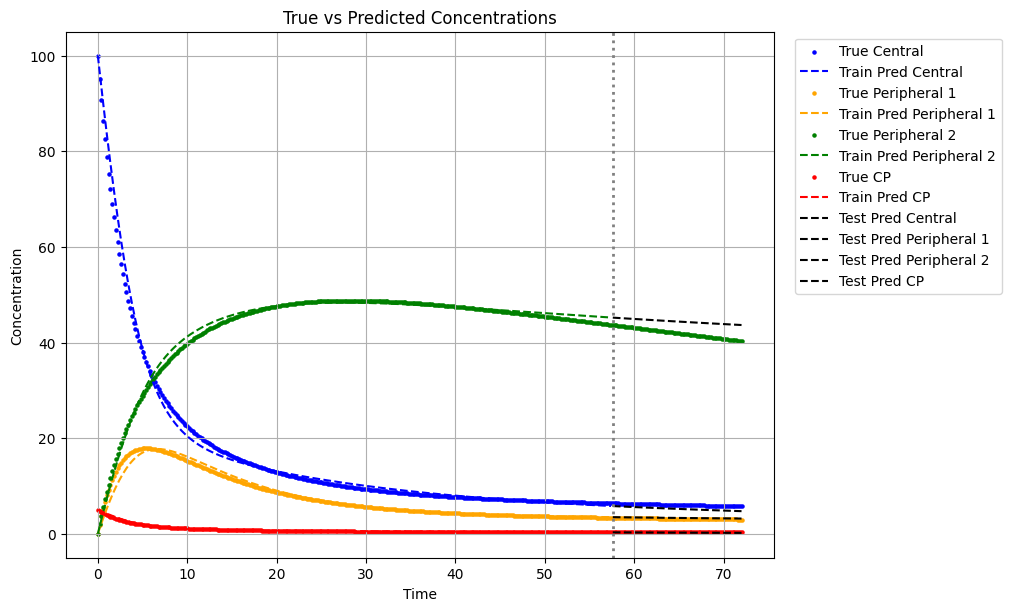

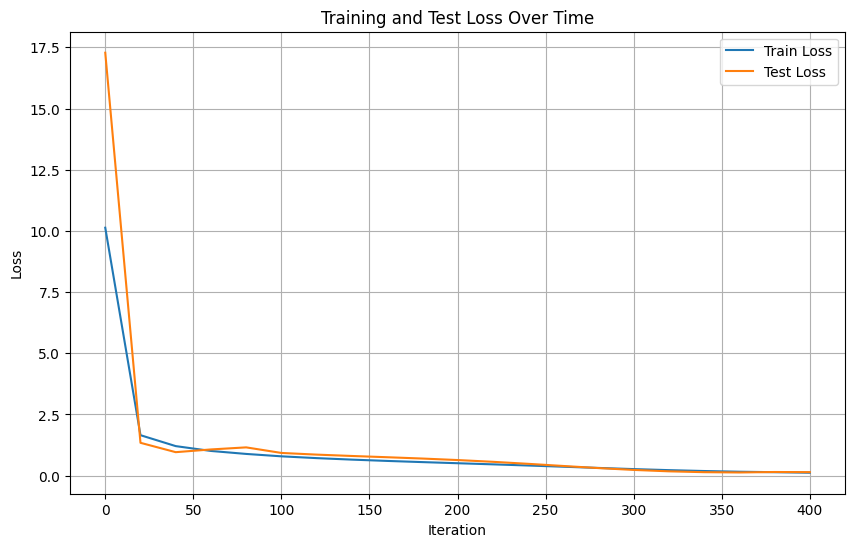

Saved GIF: training_animation.gif
Process time: 16.66 sec


In [325]:
'''
Method options for torchdiffeq.odeint:
    dopri5: Runge-Kutta of order 5 of Dormand-Prince-Shampine [default].
    dopri8 Runge-Kutta of order 8 of Dormand-Prince-Shampine.
    adaptive_heun: Runge-Kutta of order 2.
    euler: Euler method.
    midpoint: Midpoint method.
    rk4: Fourth-order Runge-Kutta with 3/8 rule.
    explicit_adams: Explicit Adams-Bashforth.
    implicit_adams: Implicit Adams-Bashforth-Moulton. 
'''
# method = ['dopri5', 'dopri8', 'adaptive_heun', 'euler', 'midpoint', 'rk4', 'explicit_adams', 'implicit_adams']

# Solve using Euler method
data_dict = data_processing(t_np, C1_np, C2_np, C3_np, C4_np, ratio=0.8, split=True)
pre_train_C, pred_test_C, func = train_NODE(data_dict, euler_solver, niters = 400, lr=5e-4, batch_size=1, method='dopri5', gif=True)

Iter 0400 | Total Loss 0.101571 | Test Loss: 0.238323


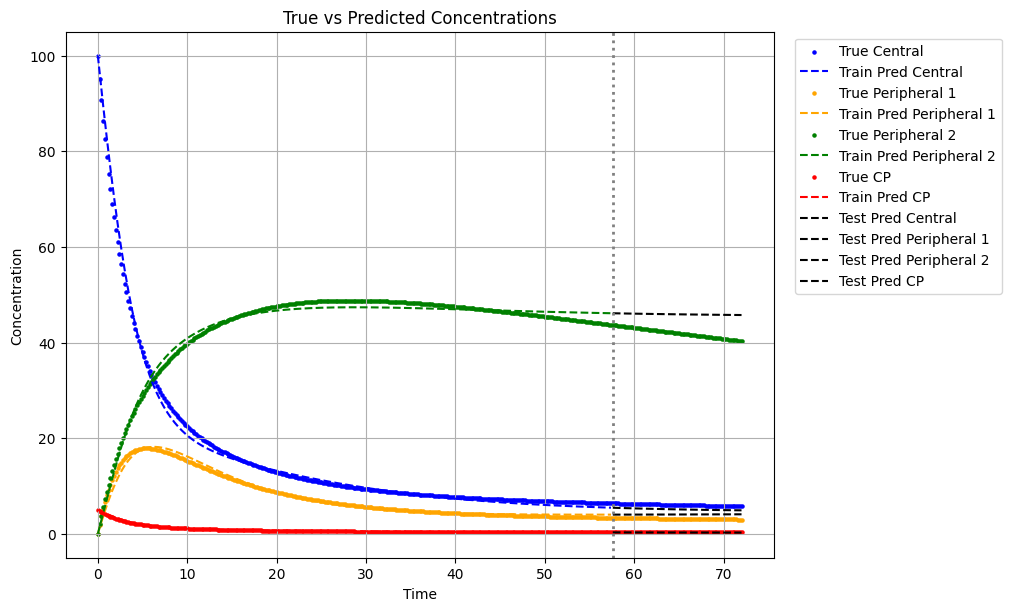

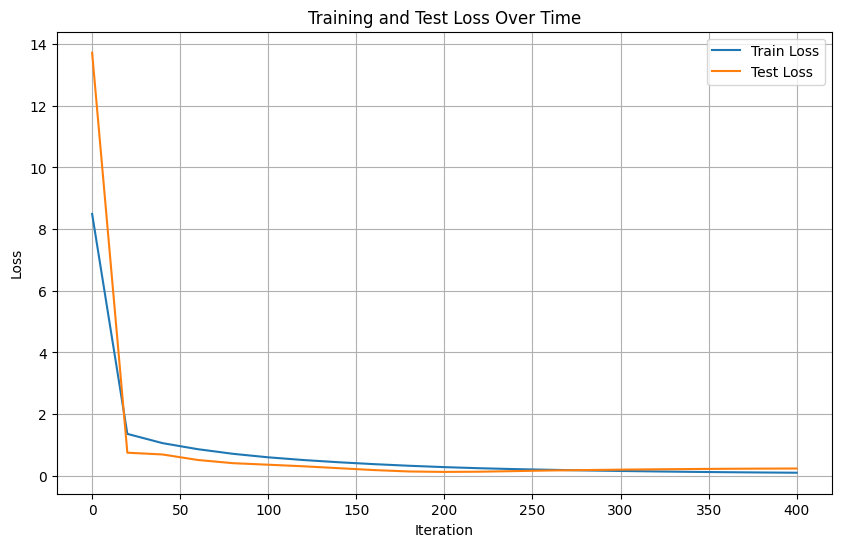

Saved GIF: training_animation.gif
Process time: 27.21 sec


In [326]:
# Solve using Improved Euler method
pre_train_C, pred_test_C, func = train_NODE(data_dict, improved_euler_solver, niters = 400, lr=5e-4, batch_size=1, method='dopri5', gif=True) 

Iter 0400 | Total Loss 0.056280 | Test Loss: 0.138876


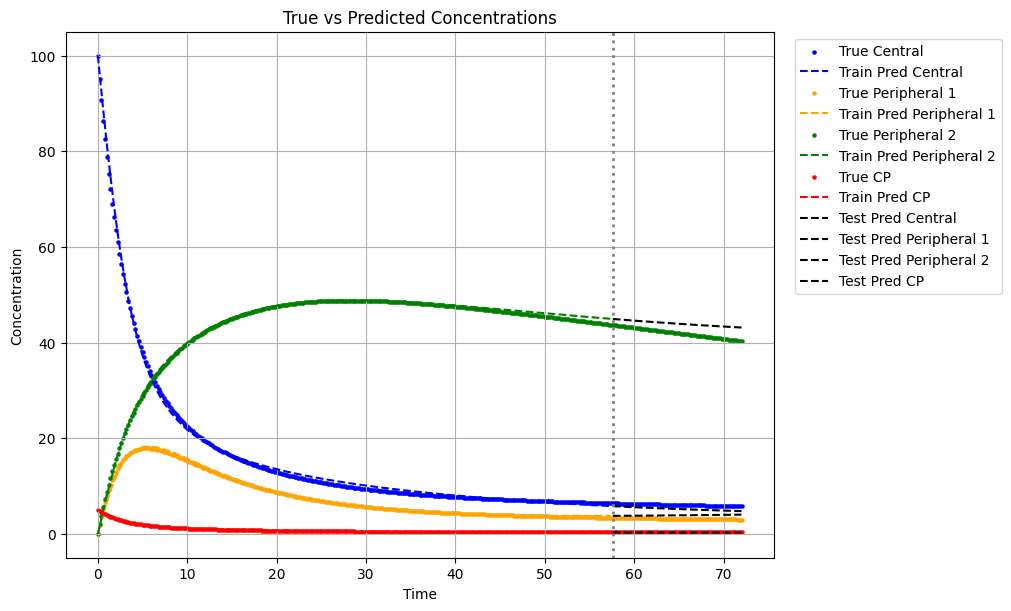

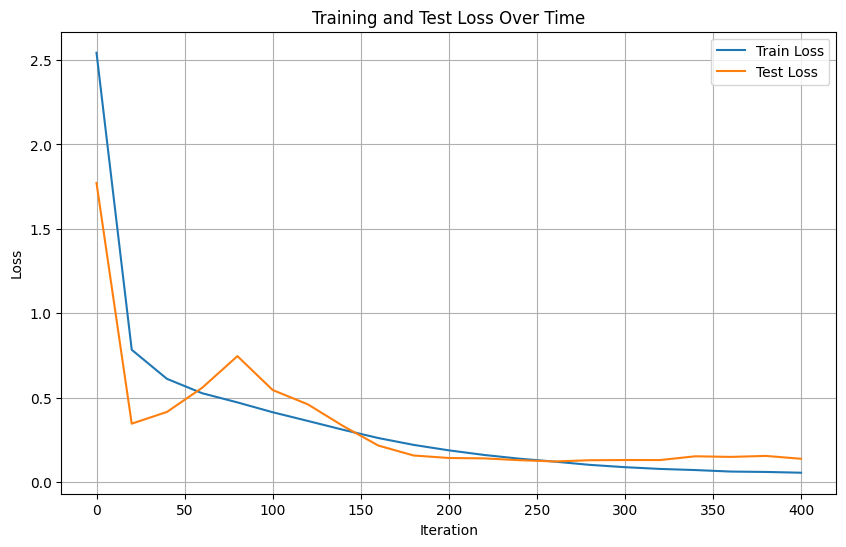

Saved GIF: training_animation.gif
Process time: 27.66 sec


In [327]:
# Solve using runge-Kutta 2th order method
pre_train_C, pred_test_C, func = train_NODE(data_dict, rk2_solver, niters = 400, lr=5e-4, batch_size=1, method='dopri5', gif=True)

In [328]:
# # Solve using runge-Kutta 4th order method
# pre_train_C, pred_test_C, func = train_NODE(data_dict, rk4_solver, niters = 400, lr=5e-4, batch_size=1, method='dopri5', gif=True)

In [329]:
print(pre_train_C.shape)
print(data_dict['train_C'].shape)

torch.Size([288, 1, 4])
torch.Size([288, 1, 4])


## Evaluation

Residual 

In [330]:
def plot_residual(t, train_C, test_C, final_train_pred, final_test_pred = None, split_idx = None):
    train_residual = (train_C - final_train_pred).squeeze(1)
    test_residual = (test_C - final_test_pred).squeeze(1) if test_C is not None else None
    colors = ['blue', 'orange', 'green', 'red']
    plt.figure(figsize=(10,6))
    if split_idx is None:
            split_idx = len(train_residual)
            print(len(train_residual))
    for i in range(4):
        plt.scatter(t[:split_idx], train_residual[:, i], color=colors[i], s=5, label=f"Train Residual {i+1}")
        if test_residual is not None:
            plt.scatter(t[split_idx:], test_residual[:, i], color='black', s=5, label=f"Test Residual {i+1}")
    if test_residual is not None:
            plt.axvline(t[split_idx], color='gray', linestyle=':', linewidth=2)
    plt.xlabel("Time")
    plt.ylabel("Residual (True - Pred)")
    plt.title("Residual vs Time (Train + Test)")
    plt.legend()
    plt.grid(True)
    plt.show()

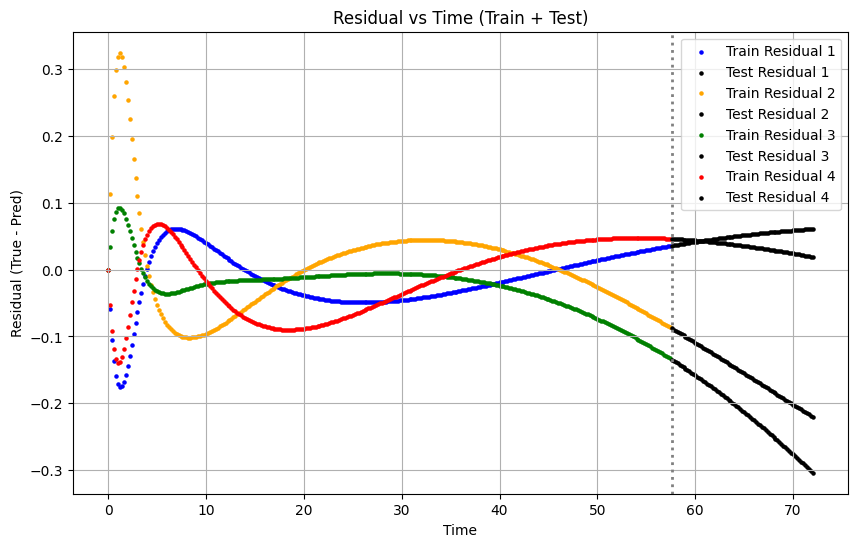

In [331]:
plot_residual(data_dict['t'], data_dict['train_C'], data_dict['test_C'], pre_train_C, pred_test_C, split_idx = data_dict['split_idx'])

In [332]:
print(data_dict['train_C'][:5])

print("__________")

print(pre_train_C[:5])

tensor([[[ 5.0525, -1.6680, -4.5882,  5.0525]],

        [[ 4.7604, -1.2588, -4.3801,  4.7604]],

        [[ 4.4874, -0.8852, -4.1829,  4.4874]],

        [[ 4.2320, -0.5446, -3.9957,  4.2320]],

        [[ 3.9931, -0.2346, -3.8180,  3.9931]]])
__________
tensor([[[ 5.0525, -1.6680, -4.5882,  5.0525]],

        [[ 4.8200, -1.3727, -4.4135,  4.8139]],

        [[ 4.5922, -1.0844, -4.2411,  4.5797]],

        [[ 4.3694, -0.8041, -4.0713,  4.3504]],

        [[ 4.1520, -0.5328, -3.9044,  4.1266]]])


Sensitivity to Initial Conditions

In [333]:
# Ininital Value Sensitivity Analysis 
def init_sensitivity(data_dict, solver, func):
    func.eval()
    train_C = data_dict['train_C']
    t = data_dict['t']
    C_0 = train_C[0, 0, :].unsqueeze(0)
    
    pred_C = solver(func, C_0, t)
    noise = 1e-4
    C_0_pert = C_0 + 1e-4 
    pred_C_pert = solver(func, C_0_pert, t)
    
    sensitivity = (pred_C_pert - pred_C)/noise 
    
    plt.plot(t.detach().numpy(), sensitivity.squeeze(1).detach().numpy())
    plt.title("Sensitivity to Initial Conditions")
    plt.xlabel("Time")
    plt.ylabel("dOutput / dC0")
    plt.grid(True)
    plt.show()
    return sensitivity 
    

Sensitivity to Neural ODE Parameters

In [334]:
def param_sensitivity(data_dict, solver, func):
    func.eval()
    train_C = data_dict['train_C']
    t = data_dict['t']
    C_0 = train_C[0, 0, :].unsqueeze(0)
    for name, p in func.named_parameters():
          print(name, p.shape)
    
    last_pred_C = solver(func, C_0, t)[-1]
    sensitivity = torch.autograd.grad(last_pred_C.sum(), func.parameters(), create_graph=True)
    # return sensitivity 
    # High value of color means very sensitive 
    for (name, p), grad in zip(func.named_parameters(), sensitivity):
        if grad.ndim == 2:  # only visualize matrices
            plt.figure(figsize=(6,4))
            sns.heatmap(grad.detach().abs().cpu(), cmap="viridis")
            plt.title(f"Sensitivity heatmap: {name}")
            plt.show()
    # flat = torch.cat([g.detach().abs().cpu().flatten() for g in sensitivity])
    # flat = flat.numpy()
    # plt.plot(flat)
    # plt.title("Sensitivity of all parameters")
    # plt.xlabel("Parameter index")
    # plt.ylabel("|Sensitivity|")
    # plt.grid(True)
    # plt.show()
    

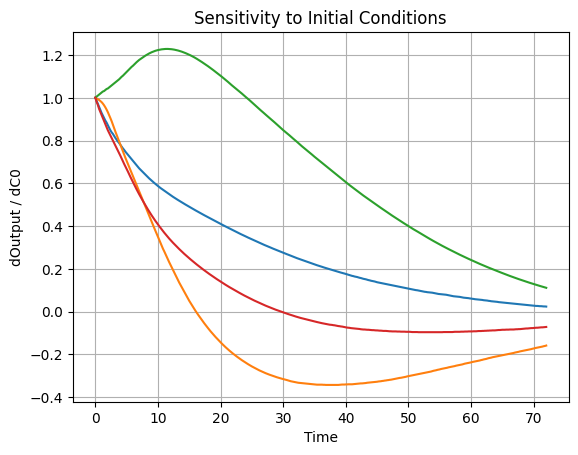

net.0.weight torch.Size([20, 4])
net.0.bias torch.Size([20])
net.2.weight torch.Size([4, 20])
net.2.bias torch.Size([4])


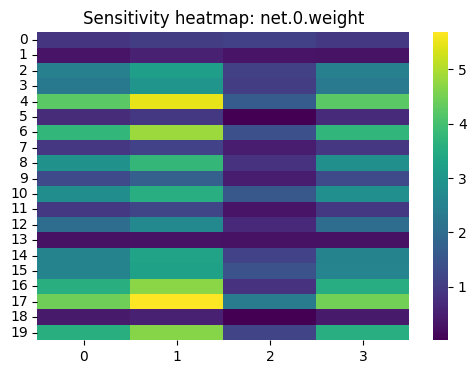

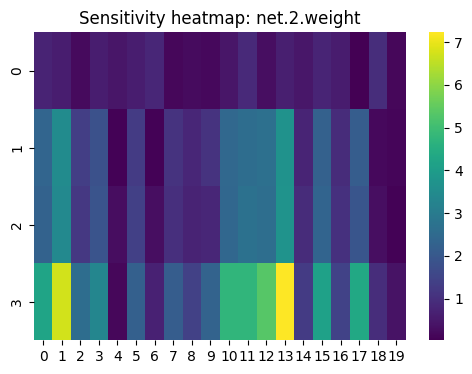

In [335]:
init_sen = init_sensitivity(data_dict, rk2_solver, func)
param_sensitivity(data_dict, rk2_solver, func)